In [631]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [632]:
df = pd.read_csv('../data/churn.csv')

In [633]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [634]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [635]:
df.drop(columns={'customerID'},inplace=True)

In [636]:
df = df[df['TotalCharges'] != ' ']

In [637]:
df.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4410,Female,0,Yes,No,16,Yes,No,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),94.65,1461.15,No
4000,Female,1,No,No,39,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.75,4036,No
1634,Male,0,Yes,Yes,63,No,No phone service,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Electronic check,59.00,3707.6,No
340,Female,1,No,No,32,Yes,No,DSL,No,Yes,No,Yes,No,No,Month-to-month,No,Bank transfer (automatic),54.65,1830.1,No
3043,Female,1,No,No,2,No,No phone service,DSL,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,30.40,78.65,Yes


In [638]:
df['TotalCharges'] = df['TotalCharges'].astype('float')

In [639]:
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [640]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  MonthlyChar

In [641]:
for i in df.columns:
    print(i,"=",df[i].unique())

gender = <StringArray>
['Female', 'Male']
Length: 2, dtype: str
SeniorCitizen = [0 1]
Partner = <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents = <StringArray>
['No', 'Yes']
Length: 2, dtype: str
tenure = [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService = <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines = <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService = <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity = <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup = <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection = <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport = <StringArray>
['No', 'Yes', 'No internet ser

In [642]:
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')
df['InternetService'] = df['InternetService'].replace({0: '0'})
for col in ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']:
    df[col] = df[col].replace('No internet service', 'No')

In [643]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [644]:
df.duplicated().sum()

np.int64(22)

In [645]:
df.drop_duplicates(inplace=True)

In [646]:
df.info()

<class 'pandas.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   str    
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   str    
 3   Dependents        7010 non-null   str    
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   str    
 6   MultipleLines     7010 non-null   str    
 7   InternetService   7010 non-null   str    
 8   OnlineSecurity    7010 non-null   str    
 9   OnlineBackup      7010 non-null   str    
 10  DeviceProtection  7010 non-null   str    
 11  TechSupport       7010 non-null   str    
 12  StreamingTV       7010 non-null   str    
 13  StreamingMovies   7010 non-null   str    
 14  Contract          7010 non-null   str    
 15  PaperlessBilling  7010 non-null   str    
 16  PaymentMethod     7010 non-null   str    
 17  MonthlyChar

In [647]:
for i in df.columns:
    print(i,"=",df[i].unique())

gender = <StringArray>
['Female', 'Male']
Length: 2, dtype: str
SeniorCitizen = [0 1]
Partner = <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents = <StringArray>
['No', 'Yes']
Length: 2, dtype: str
tenure = [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService = <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines = <StringArray>
['No', 'Yes']
Length: 2, dtype: str
InternetService = <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity = <StringArray>
['No', 'Yes']
Length: 2, dtype: str
OnlineBackup = <StringArray>
['Yes', 'No']
Length: 2, dtype: str
DeviceProtection = <StringArray>
['No', 'Yes']
Length: 2, dtype: str
TechSupport = <StringArray>
['No', 'Yes']
Length: 2, dtype: str
StreamingTV = <StringArray>
['No', 'Yes']
Length: 2, dtype: str
StreamingMovies = <

<Axes: xlabel='Churn', ylabel='count'>

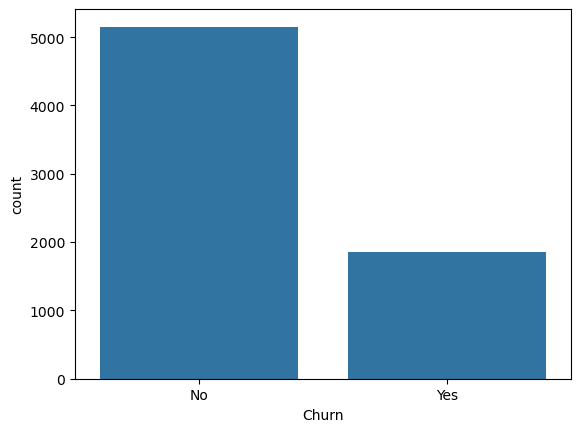

In [648]:
df['Churn'].value_counts(normalize=True)
sns.countplot(data=df, x='Churn')

<Axes: xlabel='tenure', ylabel='Count'>

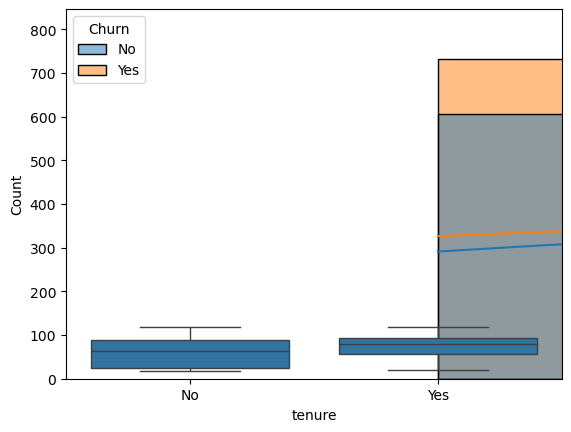

In [649]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()
sns.histplot(df, x='tenure', hue='Churn', kde=True)
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')

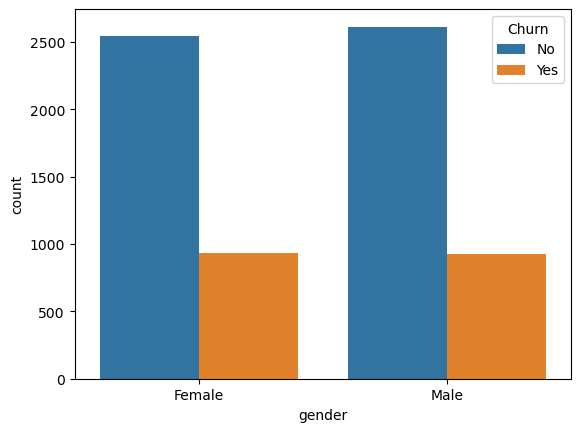

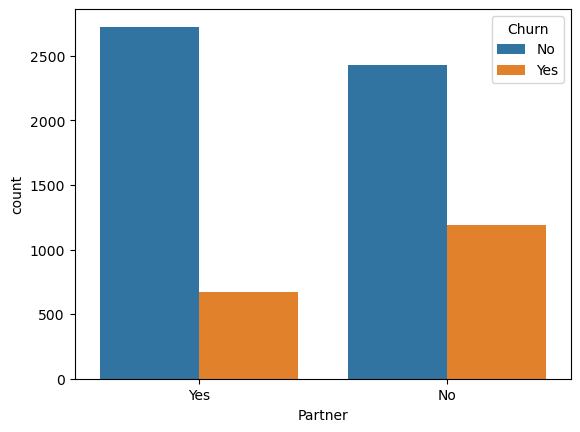

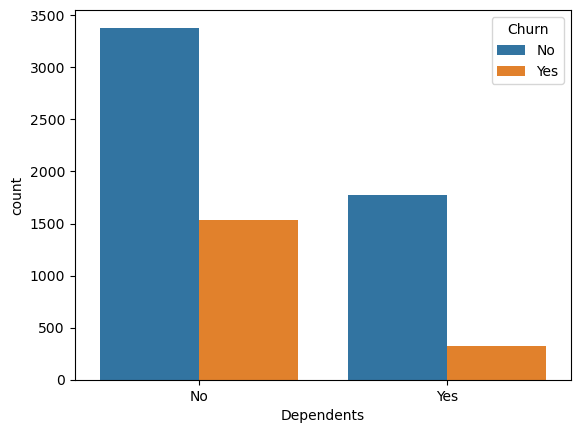

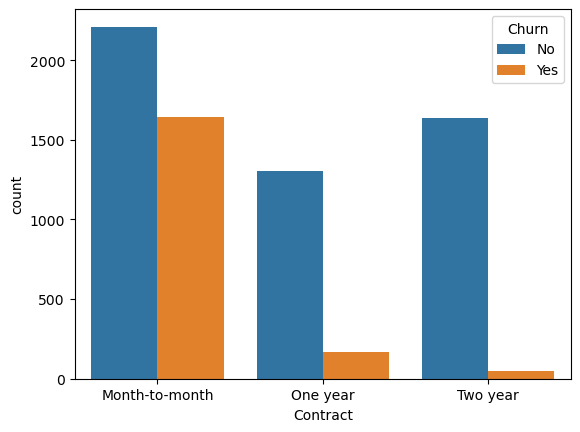

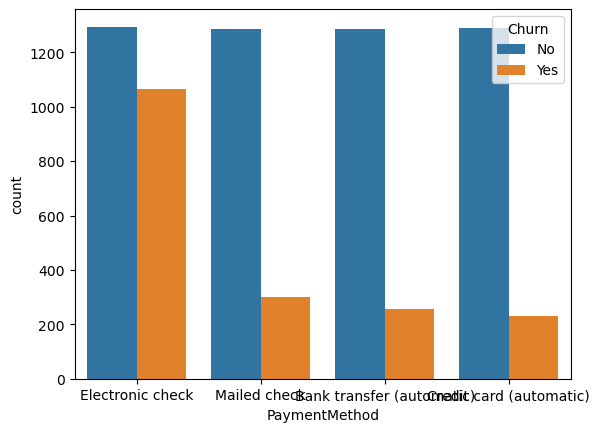

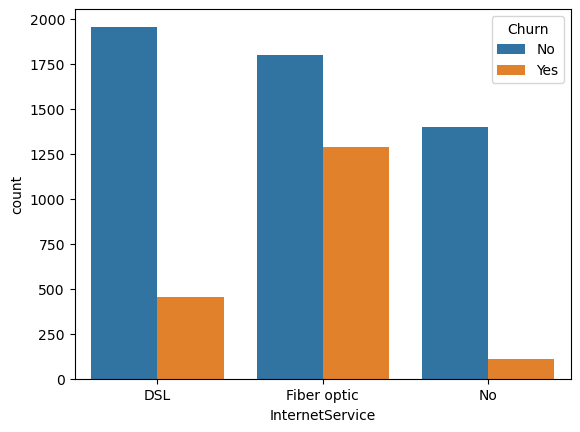

In [650]:
for col in ['gender', 'Partner', 'Dependents', 'Contract', 'PaymentMethod', 'InternetService']:
    sns.countplot(data=df, x=col, hue='Churn')
    plt.show()

<Axes: >

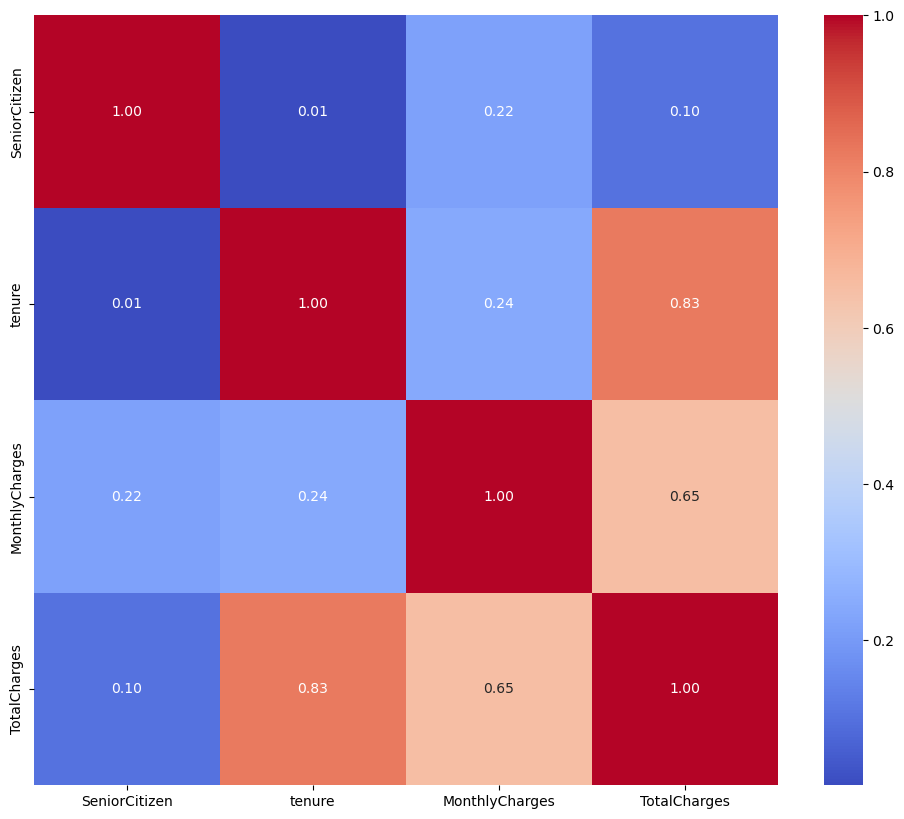

In [651]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')

In [652]:
df.info()

<class 'pandas.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   str    
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   str    
 3   Dependents        7010 non-null   str    
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   str    
 6   MultipleLines     7010 non-null   str    
 7   InternetService   7010 non-null   str    
 8   OnlineSecurity    7010 non-null   str    
 9   OnlineBackup      7010 non-null   str    
 10  DeviceProtection  7010 non-null   str    
 11  TechSupport       7010 non-null   str    
 12  StreamingTV       7010 non-null   str    
 13  StreamingMovies   7010 non-null   str    
 14  Contract          7010 non-null   str    
 15  PaperlessBilling  7010 non-null   str    
 16  PaymentMethod     7010 non-null   str    
 17  MonthlyChar

In [653]:
df['tenure'] = df['tenure'].astype(int)

In [654]:
df.shape

(7010, 20)

In [655]:
df['Churn'] = df['Churn'].map({'Yes' : 1,'No':0})

In [656]:
x = df.drop(columns=['Churn','gender'])
y = df['Churn']

In [657]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7010, dtype: int64

In [658]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer

In [659]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.25, random_state=10)

In [660]:
x_train.info()

<class 'pandas.DataFrame'>
Index: 5257 entries, 6081 to 1294
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SeniorCitizen     5257 non-null   int64  
 1   Partner           5257 non-null   str    
 2   Dependents        5257 non-null   str    
 3   tenure            5257 non-null   int64  
 4   PhoneService      5257 non-null   str    
 5   MultipleLines     5257 non-null   str    
 6   InternetService   5257 non-null   str    
 7   OnlineSecurity    5257 non-null   str    
 8   OnlineBackup      5257 non-null   str    
 9   DeviceProtection  5257 non-null   str    
 10  TechSupport       5257 non-null   str    
 11  StreamingTV       5257 non-null   str    
 12  StreamingMovies   5257 non-null   str    
 13  Contract          5257 non-null   str    
 14  PaperlessBilling  5257 non-null   str    
 15  PaymentMethod     5257 non-null   str    
 16  MonthlyCharges    5257 non-null   float64
 17  TotalCha

In [661]:
x_train

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
6081,0,No,No,1,Yes,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),49.80,49.80
5486,0,No,No,54,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),87.10,4735.20
3498,0,No,No,43,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,75.20,3198.60
3577,0,No,No,36,Yes,No,DSL,No,Yes,No,Yes,No,Yes,One year,Yes,Mailed check,65.40,2498.40
2214,0,No,No,14,Yes,No,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.30,1180.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1185,0,No,No,1,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,60.15,60.15
3455,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,90.55,90.55
1351,0,Yes,Yes,11,Yes,No,No,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.45,250.80
4642,0,Yes,Yes,65,Yes,No,DSL,Yes,No,No,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),74.80,4820.15


In [662]:
x_train.info()

<class 'pandas.DataFrame'>
Index: 5257 entries, 6081 to 1294
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SeniorCitizen     5257 non-null   int64  
 1   Partner           5257 non-null   str    
 2   Dependents        5257 non-null   str    
 3   tenure            5257 non-null   int64  
 4   PhoneService      5257 non-null   str    
 5   MultipleLines     5257 non-null   str    
 6   InternetService   5257 non-null   str    
 7   OnlineSecurity    5257 non-null   str    
 8   OnlineBackup      5257 non-null   str    
 9   DeviceProtection  5257 non-null   str    
 10  TechSupport       5257 non-null   str    
 11  StreamingTV       5257 non-null   str    
 12  StreamingMovies   5257 non-null   str    
 13  Contract          5257 non-null   str    
 14  PaperlessBilling  5257 non-null   str    
 15  PaymentMethod     5257 non-null   str    
 16  MonthlyCharges    5257 non-null   float64
 17  TotalCha

In [663]:
preprocessing = ColumnTransformer([
    ('12_ohe', OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'),[0,1,2,4,5,7,8,9,10,11,12,14]),
    ('IntSer', OrdinalEncoder(categories=[['No','DSL','Fiber optic']]),[6]),
    ('Contract', OrdinalEncoder(categories=[['Two year','One year','Month-to-month']]),[13]),
    ('PayMeth', OrdinalEncoder(),[15]),
    ('scaler', StandardScaler(),[3,16,17])
], remainder='passthrough')

In [664]:
test_me = Pipeline([
    ('preprocessing',preprocessing),
])

In [665]:
for i in x_train.columns:
    print(i,"=",x_train[i].unique())

SeniorCitizen = [0 1]
Partner = <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Dependents = <StringArray>
['No', 'Yes']
Length: 2, dtype: str
tenure = [ 1 54 43 36 14 41 53 30 23 67  4 42  7 57 40 72  5 10 34 51 45 63 58  3
 17 55 27 28 13  9 12 15  2 26 44 69 20 48  6 19 37 22 56 21 71 64  8 49
 16 68 46 62 31 29 24 11 61 47 70 33 50 25 60 35 66 59 32 18 39 38 65 52]
PhoneService = <StringArray>
['Yes', 'No']
Length: 2, dtype: str
MultipleLines = <StringArray>
['No', 'Yes']
Length: 2, dtype: str
InternetService = <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity = <StringArray>
['Yes', 'No']
Length: 2, dtype: str
OnlineBackup = <StringArray>
['No', 'Yes']
Length: 2, dtype: str
DeviceProtection = <StringArray>
['No', 'Yes']
Length: 2, dtype: str
TechSupport = <StringArray>
['No', 'Yes']
Length: 2, dtype: str
StreamingTV = <StringArray>
['No', 'Yes']
Length: 2, dtype: str
StreamingMovies = <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Contract = <Str

In [666]:
x_train['InternetService'].nunique()

3

In [667]:
x_train.nunique()

SeniorCitizen          2
Partner                2
Dependents             2
tenure                72
PhoneService           2
MultipleLines          2
InternetService        3
OnlineSecurity         2
OnlineBackup           2
DeviceProtection       2
TechSupport            2
StreamingTV            2
StreamingMovies        2
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1473
TotalCharges        4956
dtype: int64

In [668]:
x_train.head(5)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
6081,0,No,No,1,Yes,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),49.8,49.80
5486,0,No,No,54,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),87.1,4735.20
3498,0,No,No,43,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,75.2,3198.60
3577,0,No,No,36,Yes,No,DSL,No,Yes,No,Yes,No,Yes,One year,Yes,Mailed check,65.4,2498.40
2214,0,No,No,14,Yes,No,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.3,1180.95


In [669]:
x_train_trn = test_me.fit_transform(x_train)
x_test_trn = test_me.transform(x_test)

In [678]:
x_train_trn.shape

(5257, 18)

In [671]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [723]:
pipe_lr= Pipeline([
    ('preprocessing',preprocessing),
    #('pca',PCA(n_components=10)),
    ('train',lr)
])

In [724]:
np.mean(cross_val_score(pipe_lr,x,y,cv=10, scoring='accuracy'))

np.float64(0.8028530670470756)

In [688]:
y_train.value_counts(normalize=True)

Churn
0    0.737873
1    0.262127
Name: proportion, dtype: float64

In [690]:
from sklearn.metrics import classification_report, roc_auc_score

In [672]:
x_train_trn.shape

(5257, 18)

In [691]:
for i in range(1,19):
    pca = PCA(n_components=i)

    x_train_pca = pca.fit_transform(x_train_trn)
    x_test_pca = pca.transform(x_test_trn)

    lr.fit(x_train_pca,y_train)

    y_pred = lr.predict(x_test_pca)

    print(accuracy_score(y_pred=y_pred,y_true=y_test)) 

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(x_test_trn)[:, 1]))

0.7267541357672561
0.8003422703936109
0.7986309184255562
0.7992013690815745
0.8014831717056474
0.7986309184255562
0.802624073017684
0.8037649743297205
0.802624073017684
0.802624073017684
0.8014831717056474
0.8020536223616657
0.802624073017684
0.8020536223616657
0.802624073017684
0.8009127210496292
0.7963491158014832
0.7957786651454649
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1274
           1       0.65      0.56      0.60       479

    accuracy                           0.80      1753
   macro avg       0.74      0.72      0.73      1753
weighted avg       0.79      0.80      0.79      1753

ROC-AUC: 0.6981602501286366


In [683]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

In [697]:
x_train_rf = rf.fit(x_train_trn,y_train)
y_pred = y_pred = rf.predict(x_test_trn)
print(accuracy_score(y_pred=y_pred,y_true=y_test)) 

0.7775242441528808


In [725]:
pipe_rf= Pipeline([
    ('preprocessing',preprocessing),
    #('pca',PCA(n_components=10)),
    ('train',lr)
])

In [726]:
np.mean(cross_val_score(pipe_rf,x,y,cv=10, scoring='accuracy'))

np.float64(0.8028530670470756)

In [692]:
for i in range(1,19):
    pca = PCA(n_components=i)

    x_train_pca = pca.fit_transform(x_train_trn)
    x_test_pca = pca.transform(x_test_trn)

    rf.fit(x_train_pca,y_train)

    y_pred = rf.predict(x_test_pca)

    print(accuracy_score(y_pred=y_pred,y_true=y_test)) 

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(x_test_trn)[:, 1]))

0.6377638334284085
0.7586993725042784
0.764403879064461
0.7621220764403879
0.7683970336565887
0.7752424415288077
0.7769537934968626
0.7683970336565887
0.7701083856246435
0.768967484312607
0.7701083856246435
0.7661152310325157
0.7655447803764974
0.7626925270964061
0.7706788362806617
0.768967484312607
0.7649743297204792
0.7706788362806617
              precision    recall  f1-score   support

           0       0.81      0.89      0.85      1274
           1       0.61      0.45      0.52       479

    accuracy                           0.77      1753
   macro avg       0.71      0.67      0.68      1753
weighted avg       0.76      0.77      0.76      1753

ROC-AUC: 0.6219385297076917


In [693]:
from sklearn.neighbors import KNeighborsClassifier
knn= KNeighborsClassifier()

In [728]:
pipe_knn= Pipeline([
    ('preprocessing',preprocessing),
    #('pca',PCA(n_components=10)),
    ('train',knn)
])

In [729]:
np.mean(cross_val_score(pipe_knn,x,y,cv=10, scoring='accuracy'))

np.float64(0.7657631954350927)

In [698]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,      # number of trees
    max_depth=5,           # tree depth — controls complexity/overfitting
    learning_rate=0.1,     # step size shrinkage
    random_state=42
)

In [731]:
pipe_xgb= Pipeline([
    ('preprocessing',preprocessing),
    #('pca',PCA(n_components=10)),
    ('train',xgb)
])

In [732]:
np.mean(cross_val_score(pipe_knn,x,y,cv=10, scoring='accuracy'))

np.float64(0.7657631954350927)

In [734]:

models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb,
    'KNN': knn
}

for name, model in models.items():
    scores = cross_val_score(model, x_train_trn, y_train, cv=5, scoring='roc_auc')
    print(f"{name}: mean ROC-AUC = {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression: mean ROC-AUC = 0.8454 (+/- 0.0027)
Random Forest: mean ROC-AUC = 0.8277 (+/- 0.0057)
XGBoost: mean ROC-AUC = 0.8392 (+/- 0.0042)
KNN: mean ROC-AUC = 0.7858 (+/- 0.0085)


In [738]:
params = {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['lbfgs']}
grid = GridSearchCV(LogisticRegression(max_iter=1000), params, cv=5, scoring='roc_auc')
grid.fit(x_train_trn, y_train)
print(grid.best_params_, grid.best_score_)

c:\Users\annji\anaconda3\envs\first\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\annji\anaconda3\envs\first\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\annji\anaconda3\envs\first\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avo

{'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'} 0.8454693802405717


c:\Users\annji\anaconda3\envs\first\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\annji\anaconda3\envs\first\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [736]:
scores = cross_val_score(pipe_lr, x_train, y_train, cv=5, scoring='roc_auc')
print(f"pipe2 (preprocessing + LR): mean ROC-AUC = {scores.mean():.4f} (+/- {scores.std():.4f})")

pipe2 (preprocessing + LR): mean ROC-AUC = 0.8455 (+/- 0.0028)
